# ForecastLab — EXP-012 Hyperparameter Tuning

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-012 |
| **Dataset** | featured_data.csv |
| **Author** | GAKUSEI Najib |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
import xgboost as xgb
import joblib
import json
import os
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

target = 'PowerConsumption_Zone1'
exclude = ['Datetime', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
feature_cols = [c for c in df.columns if c not in exclude and c != target]

train = df[df['Datetime'] < '2017-07-01']
test  = df[df['Datetime'] >= '2017-07-01']
X_train, y_train = train[feature_cols].fillna(0), train[target]
X_test, y_test = test[feature_cols].fillna(0), test[target]
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (25920, 43), X_test: (26352, 43)


In [2]:
param_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.8, 1.0],
}

t0 = time.time()
grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42), param_grid, cv=3,
    scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)
tuning_time = time.time() - t0
print(f'Grid Search selesai ({tuning_time:.2f}s)')
print(f'Best params: {grid.best_params_}')
print(f'Best CV MAE: {-grid.best_score_:.2f}')

Fitting 3 folds for each of 36 candidates, totalling 108 fits


Grid Search selesai (56.40s)
Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV MAE: 276.75


In [3]:
best_model = grid.best_estimator_
y_pred_test = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / (y_test + 1e-10))) * 100
r2 = r2_score(y_test, y_pred_test)
print(f'XGBoost Tuned: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.1f}%, R2={r2:.4f}')

XGBoost Tuned: MAE=343.20, RMSE=548.17, MAPE=1.0%, R2=0.9941


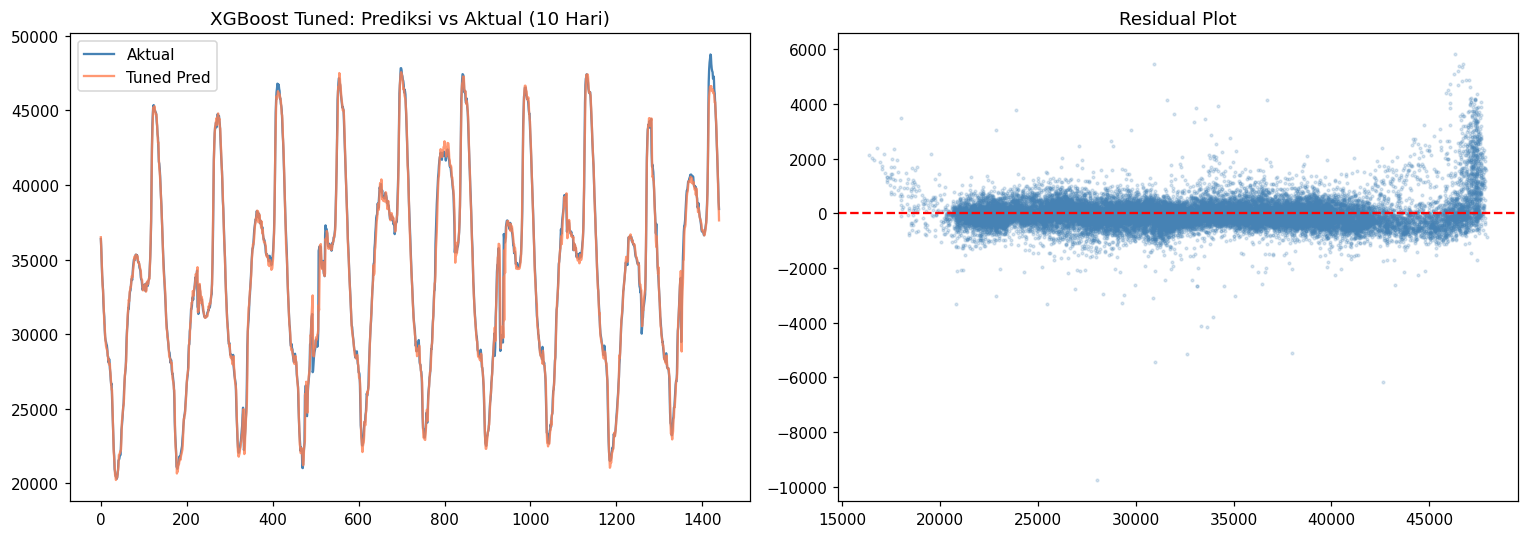

In [4]:
n_show = 1440
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(n_show), y_test.values[:n_show], label='Aktual', color='steelblue')
axes[0].plot(range(n_show), y_pred_test[:n_show], label='Tuned Pred', color='coral', alpha=0.8)
axes[0].set_title('XGBoost Tuned: Prediksi vs Aktual (10 Hari)')
axes[0].legend()
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.2, s=3, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('../data/tuned_01_prediction.png', bbox_inches='tight', dpi=110)
plt.show()

In [5]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
metadata = {
    'model_name': 'XGBoost Tuned',
    'version': '1.0.0',
    'dataset': 'featured_data.csv',
    'features': feature_cols,
    'best_params': grid.best_params_,
    'metrics': {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2},
    'tuning_time_seconds': round(tuning_time, 2),
    'created_at': pd.Timestamp.now().isoformat()
}
with open('../models/best_model.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print('Model dan metadata berhasil disimpan.')

Model dan metadata berhasil disimpan.


---
## Kesimpulan

Grid Search menemukan hyperparameter optimal. Model terbaik disimpan untuk EXP-013 & EXP-014.

**Next: EXP-013 Model Evaluation**